# Notebook 2 — Dot plot: chrF++ a nivel segmento vs juicio humano

Cruza el **chrF++ por segmento** del sistema evaluado (`v2-nostrat`) con los
**juicios humanos** de una lingüista con experiencia en qom.

### Los datos de juicio humano

- Segmentos evaluados en **ambas direcciones** (`qom2es` y `es2qom`), en un mismo CSV
  (una fila por segmento y dirección; la dirección va en la columna `direction`).
- Las oraciones **se eligieron sin garantizar que vinieran de un split de test**
  controlado, así que su `segment_id` se recupera por texto contra el corpus `qomL-hf`
  completo, y la hipótesis se toma de la columna con la predicción del sistema.
- Juicios **categóricos** (aproximadamente: correcto / incorrecto / dudoso).
- **No siguen el esquema MQM**: la tipificación MQM es una relectura posterior, así que
  **no hay severidades ni puntajes numéricos**.

> **No** se inventa un escalar de calidad ni se deriva uno a partir de las categorías.
> El origen no controlado de los segmentos es una limitación a declarar en la lectura.

### La pregunta de la figura

¿Los segmentos juzgados **incorrectos** se separan de los **correctos** en el eje de
chrF++, o se mezclan?

## Celda de configuración

Requiere que la **Notebook 1** haya corrido antes (produce `results/chrf_por_segmento.csv`
y `results/traducciones_tidy.csv`). **Completá `JUICIOS_CSV`** (columnas `segment_id,
direction, juicio_humano`) y, si querés, fijá `SISTEMA_EVALUADO`.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd

RANDOM_STATE = 20260729
np.random.seed(RANDOM_STATE)

# ── Entradas ──────────────────────────────────────────────────────────────────
DATA_DIR = Path("data")
# CSV de juicios. Puede NO traer segment_id: se recupera por texto desde qomL-hf.
# Columnas mínimas: direction, juicio (+ texto qom/es para recuperar el id).
JUICIOS_CSV = DATA_DIR / "human_eval/v2-nostrat.csv"

# Corpus completo empaquetado (parquet por config y split). De acá se recuperan
# los segment_id de TODOS los segmentos (no sólo del test común de Base).
QOML_HF_DIR = DATA_DIR / "qomL-hf"

# Salidas de la Notebook 1 (opcionales acá: sólo se usan como atajo si existen).
RESULTS_DIR = Path("data/results")
SEGMENT_CHRF_CSV = RESULTS_DIR / "chrf_por_segmento.csv"
TIDY_CSV         = RESULTS_DIR / "traducciones_tidy.csv"

FIG_DIR = Path("poster/figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# n mínimo por categoría para calcular correlaciones/tests.
N_MINIMO_TESTS = 10
N_BOOTSTRAP = 100

# Sistema cuyas salidas evaluó la lingüista.
SISTEMA_EVALUADO = "qom-mt-v2-aleatorio"

# Hipótesis del sistema evaluado
COL_PREDICCION_INLINE = "v2-nostrat"

DIRECTION_LANGS = {"qom2es": ("qom", "es"), "es2qom": ("es", "qom")}

## 2.1 — Datos: hipótesis, referencia y chrF++ por segmento

El CSV trae, por fila: `direction`, el **texto fuente** y la **referencia** (columnas
`text_source` / `text_reference`), la **predicción** del sistema evaluado (columna
`v2-nostrat`) y el `juicio` de la lingüista. Con eso:

1. **chrF++ por segmento** se calcula directo: `chrF++(predicción, text_reference)`.
   No depende de que el segmento esté en el test común ni en `chrf_por_segmento.csv`.
2. **`segment_id`** se recupera contra `qomL-hf` **solo para trazabilidad** (linkear cada
   oración al corpus): es **no bloqueante**, si no matchea la fila igual entra al dot plot.

> Compatibilidad: si el CSV todavía usa `qom`/`es` en vez de `text_source`/`text_reference`,
> la notebook lo detecta y resuelve el orden probando ambas orientaciones (en `es2qom` esas
> columnas venían invertidas). Lo recomendado es usar `text_source`/`text_reference`.

> Limitación: los segmentos no salen de un split de test controlado. Se declara en la lectura.

In [8]:
import re
import unicodedata

# ── Normalización de direcciones ──────────────────────────────────────────────
DIRECTION_ALIASES = {
    "qom2es": "qom2es", "qom-es": "qom2es", "qom_es": "qom2es", "qomes": "qom2es",
    "qom->es": "qom2es", "qom→es": "qom2es", "tob2spa": "qom2es",
    "es2qom": "es2qom", "es-qom": "es2qom", "es_qom": "es2qom", "esqom": "es2qom",
    "es->qom": "es2qom", "es→qom": "es2qom", "spa2tob": "es2qom",
}
def norm_direction(v):
    k = str(v).strip().lower().replace(" ", "")
    if k in DIRECTION_ALIASES:
        return DIRECTION_ALIASES[k]
    raise ValueError(f"Dirección no reconocida: {v!r}. Agregala a DIRECTION_ALIASES.")

_PUNT = re.compile(r"[^\w\s]", flags=re.UNICODE)
_ESP  = re.compile(r"\s+")
def normalizar_texto(t):
    t = unicodedata.normalize("NFC", str(t)).lower()
    t = _PUNT.sub(" ", t); t = _ESP.sub(" ", t).strip()
    return t

CATEGORIAS_ESPERADAS = {"correcto", "incorrecto", "dudoso"}
CAT_ALIASES = {
    "correcto": "correcto", "correcta": "correcto", "ok": "correcto", "bien": "correcto",
    "si": "correcto", "sí": "correcto", "1": "correcto",
    "incorrecto": "incorrecto", "incorrecta": "incorrecto", "mal": "incorrecto",
    "no": "incorrecto", "0": "incorrecto",
    "dudoso": "dudoso", "dudosa": "dudoso", "duda": "dudoso", "?": "dudoso",
    "parcial": "dudoso",
}
def norm_categoria(v):
    return CAT_ALIASES.get(str(v).strip().lower(), str(v).strip().lower())

def _candidatos_col_pred(sistema):
    s = sistema.lower().replace("qom-mt-", "").replace("qom_mt_", "")
    s = s.replace("aleatorio", "nostrat").replace("estratificado", "strat")
    out, vistos = [], set()
    for c in [sistema, s, s.replace("-", "_"), s.replace("_", "-")]:
        if c and c not in vistos: vistos.add(c); out.append(c)
    return out

# ── Carga del CSV de juicios ──────────────────────────────────────────────────
jr = pd.read_csv(JUICIOS_CSV)
lower = {c.lower().strip(): c for c in jr.columns}
def _col(*cands, req=True):
    for c in cands:
        if c in lower: return lower[c]
    if req: raise ValueError(f"Falta alguna de estas columnas en {JUICIOS_CSV}: {cands}")
    return None

col_dir    = _col("direction", "dir", "sentido", "direccion", "dirección")
col_juicio = _col("juicio_humano", "juicio", "categoria", "categoría", "label",
                  "evaluacion", "evaluación")
# Preferimos columnas por ROL (fuente/referencia); si no, caemos a qom/es.
col_ts = _col("text_source", "source_text", "texto_fuente", "fuente", "src", req=False)
col_tr = _col("text_reference", "reference_text", "texto_referencia", "referencia",
              "reference", "ref", req=False)
col_qom = _col("qom", "toba", "tob", req=False)
col_es  = _col("es", "spa", "español", "espanol", "castellano", req=False)

j = pd.DataFrame({
    "direction":     jr[col_dir].map(norm_direction),
    "juicio_humano": jr[col_juicio].map(norm_categoria),
})
j["text_source"]    = jr[col_ts].astype("string")
j["text_reference"] = jr[col_tr].astype("string")

if _col("segment_id", "seg_id", req=False):
    j["segment_id"] = jr[_col("segment_id", "seg_id")]

# Predicción inline del sistema evaluado.
j["hyp_inline"] = jr[COL_PREDICCION_INLINE].astype("string")

inesperadas = set(j["juicio_humano"]) - CATEGORIAS_ESPERADAS
if inesperadas:
    print(f"[aviso] Categorías fuera de {CATEGORIAS_ESPERADAS}: {inesperadas}.")

print(j.groupby(["direction", "juicio_humano"]).size().to_string())
print("Columna de predicción inline:", COL_PREDICCION_INLINE)

direction  juicio_humano
es2qom     correcto         25
           dudoso            1
           incorrecto        2
qom2es     correcto         23
           incorrecto        5
Columna de predicción inline: v2-nostrat


In [10]:
# ── Recuperar segment_id + split/fuente desde qomL-hf (TRAZABILIDAD) ──────────
# Por cada segmento evaluado respondemos dos preguntas:
#   (1) ¿en qué split del MODELO EVALUADO (v2-nostrat) estuvo?
#         · en_train        -> ⚠ contaminación (el modelo ya vio ese par)
#         · solo_test / solo_validation -> limpio (no lo vio al entrenar)
#         · fuera_del_modelo -> está en el corpus pero no en el config de v2-nostrat
#   (2) ¿de qué fuente/género proviene? (columna `source` de qomL-hf), para
#       analizar en qué tipos de fuente falla.
from difflib import SequenceMatcher

UMBRAL_DIFUSO = 0.90
RECUPERAR_ID = True      # necesita el corpus qomL-hf en QOML_HF_DIR

def _config_preferida(sistema):
    s = sistema.lower().replace("qom-mt-", "").replace("qom_mt_", "")
    return s.replace("aleatorio", "nostrat").replace("estratificado", "strat")

CONFIG_EVALUADO = _config_preferida(SISTEMA_EVALUADO)   # p.ej. "v2-nostrat"

_PRIO = {"par_exacto": 3, "solo_qom": 2, "solo_es": 2, "difuso_qom": 1, "sin_match": 0}

def _qom_es_por_fila(row):
    """(qom_text, es_text) de la fila según la dirección (columnas por rol)."""
    s, r = row.text_source, row.text_reference
    return (s, r) if row.direction == "qom2es" else (r, s)   # qom2es: src=qom

def _indice_qomL_hf_full():
    parquets = sorted(QOML_HF_DIR.glob("*/*.parquet"))
    if not parquets:
        raise FileNotFoundError(f"No hay parquets en {QOML_HF_DIR}/*/*.parquet.")
    trozos = []
    for p in parquets:
        df = pd.read_parquet(p)
        if not {"qom", "es"} <= set(df.columns):
            print(f"[aviso] {p} sin columnas qom/es: se saltea."); continue
        sub = df[["qom", "es"]].copy()
        sub["hf_id"]  = df["id"]     if "id"     in df.columns else pd.NA
        sub["fuente"] = df["source"] if "source" in df.columns else pd.NA
        sub["config"] = p.parent.name
        sub["split"]  = p.stem
        trozos.append(sub[["hf_id", "fuente", "config", "split", "qom", "es"]])
    full = pd.concat(trozos, ignore_index=True).dropna(subset=["qom", "es"])
    full["qom_norm"] = full["qom"].map(normalizar_texto)
    full["es_norm"]  = full["es"].map(normalizar_texto)
    return full

def _estado(splits):
    partes = [x for x in str(splits).split(";") if x] if splits else []
    if not partes:
        return "fuera_del_modelo"          # en el corpus pero no en el config evaluado
    if "train" in partes:
        return "en_train"                  # ⚠ contaminación
    return "solo_" + "/".join(partes)      # p.ej. solo_test (limpio)

def recuperar_segment_ids(j):
    full = _indice_qomL_hf_full()

    # Filas del MODELO EVALUADO (config v2-nostrat) para determinar el split.
    es_eval = full["config"].str.contains(CONFIG_EVALUADO, case=False, na=False, regex=False)
    sys_rows = full[es_eval]
    if sys_rows.empty:
        print(f"[aviso] No encontré el config '{CONFIG_EVALUADO}' en qomL-hf: no puedo "
              f"determinar el split del modelo. ¿Está data/qomL-hf/{CONFIG_EVALUADO}/?")
    pair_splits = (sys_rows.groupby(["qom_norm", "es_norm"])["split"]
                   .agg(lambda s: ";".join(sorted(set(s)))).to_dict())
    prov_sys = (sys_rows.drop_duplicates(["qom_norm", "es_norm"])
                .set_index(["qom_norm", "es_norm"])["fuente"].to_dict())
    prov_any = (full.drop_duplicates(["qom_norm", "es_norm"])
                .set_index(["qom_norm", "es_norm"])["fuente"].to_dict())
    def _fuente(key):
        v = prov_sys.get(key)
        if v is None or pd.isna(v):
            v = prov_any.get(key)
        return v

    # Índice deduplicado para asignar segment_id + gold (preferimos el config evaluado).
    idx = full.copy()
    idx["_pref"] = (~es_eval.values).astype(int)
    idx = (idx.sort_values(["_pref", "config", "split"])
              .drop_duplicates(["qom_norm", "es_norm"], keep="first").reset_index(drop=True))
    idx["segment_id"] = [r.hf_id if pd.notna(r.hf_id) else f"{r.config}:{r.split}:{i}"
                         for i, r in enumerate(idx.itertuples(index=False))]

    by_pair, by_qom, by_es, reg = {}, {}, {}, {}
    for r in idx.itertuples(index=False):
        by_pair.setdefault((r.qom_norm, r.es_norm), r.segment_id)
        by_qom.setdefault(r.qom_norm, set()).add(r.segment_id)
        by_es.setdefault(r.es_norm, set()).add(r.segment_id)
        key = (r.qom_norm, r.es_norm)
        reg[r.segment_id] = (r.qom, r.es, _fuente(key), pair_splits.get(key, ""))
    universo_qom = list(by_qom)

    def _match(qn, en):
        if qn and en and (qn, en) in by_pair: return by_pair[(qn, en)], "par_exacto", 1.0
        if qn and len(by_qom.get(qn, ())) == 1: return next(iter(by_qom[qn])), "solo_qom", 1.0
        if en and len(by_es.get(en, ())) == 1: return next(iter(by_es[en])), "solo_es", 1.0
        if qn:
            mejor, ms = None, 0.0
            for cand in universo_qom:
                v = SequenceMatcher(None, qn, cand).ratio()
                if v > ms: mejor, ms = cand, v
            if mejor is not None and ms >= UMBRAL_DIFUSO and len(by_qom[mejor]) == 1:
                return next(iter(by_qom[mejor])), "difuso_qom", round(ms, 3)
        return None, "sin_match", float("nan")

    sids, met, sc, gq_l, ge_l, fu_l, sp_l, est_l = [], [], [], [], [], [], [], []
    for row in j.itertuples(index=False):
        qt, et = _qom_es_por_fila(row)
        qn = normalizar_texto(qt) if pd.notna(qt) else None
        en = normalizar_texto(et) if pd.notna(et) else None
        rA = _match(qn, en); rB = _match(en, qn)
        best = rB if _PRIO[rB[1]] > _PRIO[rA[1]] else rA
        sid = best[0]
        sids.append(sid); met.append(best[1]); sc.append(best[2])
        gq, ge, fuente, splits = reg.get(sid, (None, None, None, ""))
        gq_l.append(gq); ge_l.append(ge); fu_l.append(fuente)
        sp_l.append(splits if sid is not None and splits else pd.NA)
        est_l.append(_estado(splits) if sid is not None else "sin_match")
    out = j.copy()
    out["segment_id"]   = sids
    out["match_metodo"] = met
    out["match_score"]  = sc
    out["_gold_qom"]    = pd.array(gq_l, dtype="string")
    out["_gold_es"]     = pd.array(ge_l, dtype="string")
    out["fuente"]               = pd.array(fu_l, dtype="string")
    out["split_modelo"]         = pd.array(sp_l, dtype="string")
    out["estado_contaminacion"] = pd.array(est_l, dtype="string")
    return out

_COLS_EXTRA = ["fuente", "split_modelo", "estado_contaminacion"]

if "segment_id" in j.columns and j["segment_id"].notna().all():
    print("El CSV ya trae segment_id: se usa tal cual (no se recupera split/fuente).")
    j["match_metodo"] = "provisto"; j["match_score"] = 1.0
    j["_gold_qom"] = pd.NA; j["_gold_es"] = pd.NA
    for c in _COLS_EXTRA: j[c] = pd.NA
elif RECUPERAR_ID:
    j = recuperar_segment_ids(j)
    print("Recuperación de segment_id (trazabilidad):")
    print(j["match_metodo"].value_counts().to_string())
    n_sin = int(j["segment_id"].isna().sum())
    if n_sin:
        print(f"[nota] {n_sin} fila(s) sin segment_id en qomL-hf. NO se descartan: "
              "el chrF++ no depende del id. (Esperable si no salieron de un split.)")

    print(f"\n== Estado en el modelo evaluado ({CONFIG_EVALUADO}) ==")
    print(j["estado_contaminacion"].value_counts(dropna=False).to_string())
    print("\nEstado x juicio (¿los 'correcto' son limpios o estaban en train?):")
    print(pd.crosstab(j["estado_contaminacion"], j["juicio_humano"]).to_string())
    print("\n== Fuentes de los segmentos evaluados ==")
    print(j["fuente"].value_counts(dropna=False).to_string())
else:
    print("Sin recuperación de segment_id (RECUPERAR_ID=False).")
    j["segment_id"] = j.get("segment_id", pd.Series([pd.NA] * len(j)))
    j["match_metodo"] = "no_recuperado"; j["match_score"] = float("nan")
    j["_gold_qom"] = pd.NA; j["_gold_es"] = pd.NA
    for c in _COLS_EXTRA: j[c] = pd.NA

JUICIOS_CON_ID = RESULTS_DIR / "juicios_con_id.csv"
j.to_csv(JUICIOS_CON_ID, index=False)
print(f"\nJuicios (con segment_id / split / fuente) -> {JUICIOS_CON_ID}")

Sin recuperación de segment_id (RECUPERAR_ID=False o sin texto).
Juicios (con segment_id si hubo) -> data/results/juicios_con_id.csv


In [11]:
from sacrebleu.metrics import CHRF
chrf_pp = CHRF(word_order=2)   # chrF++ (char_order=6, beta=2)

# ── Texto FUENTE y REFERENCIA por fila ────────────────────────────────────────
# Directo del CSV: es lo que usó la lingüista. No depende de qomL-hf.
j["source"]    = j["text_source"]
j["reference"] = j["text_reference"]

# ── Hipótesis del sistema evaluado ────────────────────────────────────────────
if "hyp_inline" in j.columns and j["hyp_inline"].notna().any():
    j["hypothesis"] = j["hyp_inline"].astype("string")
    print(f"Hipótesis desde columna inline: {j['hypothesis'].notna().sum()}/{len(j)} filas.")
else:
    j["hypothesis"] = pd.Series([pd.NA] * len(j), dtype="string")
    print("No hay columna inline de predicción.")

print(f"Hipótesis faltantes (requieren correr el modelo): {int(j['hypothesis'].isna().sum())}")

Hipótesis desde columna inline: 56/56 filas.
Hipótesis faltantes (requieren correr el modelo): 0


In [12]:
# ── chrF++ por segmento (hyp vs ref) y armado de `datos` ──────────────────────
listo = j.dropna(subset=["hypothesis", "reference"]).copy()
listo = listo[listo["hypothesis"].astype(str).str.len() > 0]
listo["chrf_segment"] = [
    round(chrf_pp.sentence_score(str(h), [str(r)]).score, 4)
    for h, r in zip(listo["hypothesis"], listo["reference"])
]

datos = (listo[["segment_id", "direction", "juicio_humano", "chrf_segment",
                "source", "reference", "hypothesis"]]
         .reset_index(drop=True))
sistema = SISTEMA_EVALUADO   # lo usan las celdas siguientes

n_fuera = len(j) - len(datos)
if n_fuera:
    print(f"[aviso] {n_fuera} fila(s) sin hipótesis quedaron fuera del cruce "
          "(faltó generarlas o venían vacías).")
print(f"Segmentos con chrF++ para el dot plot: {len(datos)} (sistema: {sistema}).")
if len(datos):
    print(datos.groupby(["direction", "juicio_humano"]).size().to_string())
datos.to_csv(RESULTS_DIR / "juicio_vs_chrf.csv", index=False)

Segmentos con chrF++ para el dot plot: 56 (sistema: qom-mt-v2-aleatorio).
direction  juicio_humano
es2qom     correcto         25
           dudoso            1
           incorrecto        2
qom2es     correcto         23
           incorrecto        5


## 2.2 — Figura principal (dot plot)

Un panel por dirección:

- eje **Y**: chrF++ del segmento;
- eje **X**: categoría de juicio humano, con **jitter** horizontal;
- **color y forma** de marcador según categoría (paleta apta para daltonismo);
- **mediana** de cada grupo con línea horizontal;
- **puntos individuales visibles**: no boxplot ni violín (con este n no corresponde).

  guardada: figura_dotplot_juicio_chrf.pdf y .png (300 dpi)


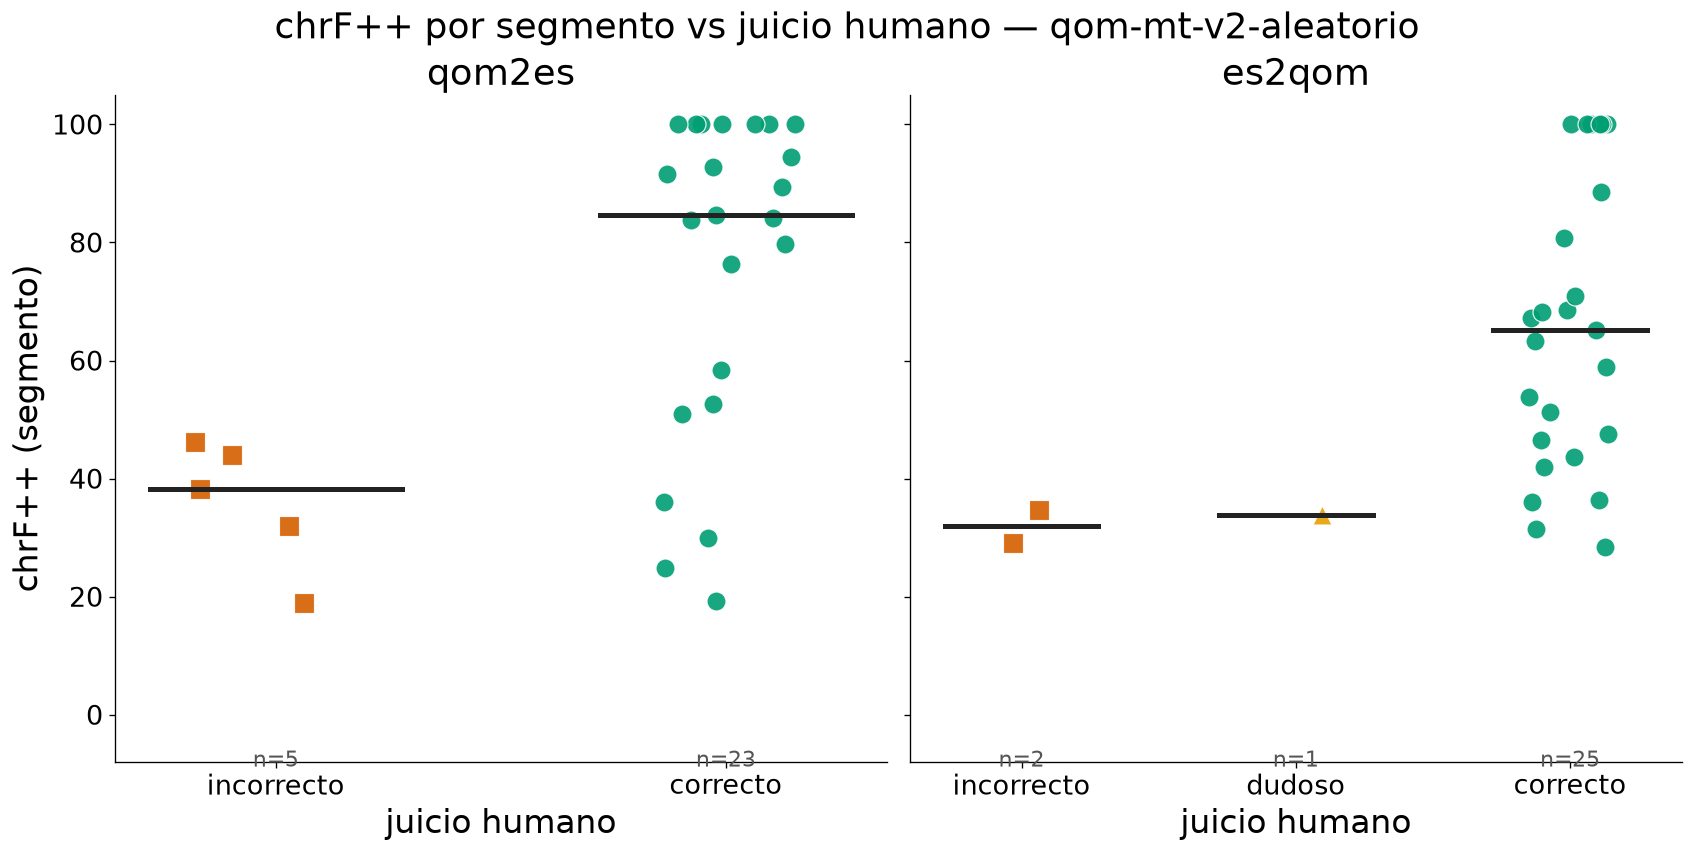

In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300,
    "font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
    "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 16,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True,
})

# Okabe-Ito: color + forma redundantes por categoría (accesibilidad).
ESTILO_CAT = {
    "correcto":   {"color": "#009E73", "marker": "o"},   # verde, círculo
    "dudoso":     {"color": "#E69F00", "marker": "^"},   # naranja, triángulo
    "incorrecto": {"color": "#D55E00", "marker": "s"},   # bermellón, cuadrado
}
ORDEN_CAT = ["incorrecto", "dudoso", "correcto"]

def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{nombre}.png", bbox_inches="tight", dpi=300)
    print(f"  guardada: {nombre}.pdf y .png (300 dpi)")

rng = np.random.default_rng(RANDOM_STATE)
direcciones = [d for d in ["qom2es", "es2qom"] if d in set(datos["direction"])]

fig, axes = plt.subplots(1, len(direcciones), figsize=(7 * len(direcciones), 7),
                         sharey=True, squeeze=False)
axes = axes[0]
for ax, direccion in zip(axes, direcciones):
    d = datos[datos["direction"] == direccion]
    cats = [c for c in ORDEN_CAT if c in set(d["juicio_humano"])]
    cats += [c for c in sorted(set(d["juicio_humano"])) if c not in cats]
    for x, cat in enumerate(cats):
        g = d[d["juicio_humano"] == cat]
        est = ESTILO_CAT.get(cat, {"color": "#0072B2", "marker": "D"})
        jitter = rng.uniform(-0.18, 0.18, size=len(g))
        ax.scatter(np.full(len(g), x) + jitter, g["chrf_segment"],
                   color=est["color"], marker=est["marker"], s=130,
                   edgecolor="white", linewidth=0.7, alpha=0.9, zorder=3)
        med = g["chrf_segment"].median()
        ax.plot([x - 0.28, x + 0.28], [med, med], color="#222222", lw=3, zorder=4)
        ax.text(x, -6, f"n={len(g)}", ha="center", va="top", fontsize=13, color="#555")
    ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats)
    ax.set_title(direccion); ax.set_xlabel("juicio humano")
    ax.set_ylim(-8, 105)
axes[0].set_ylabel("chrF++ (segmento)")
fig.suptitle(f"chrF++ por segmento vs juicio humano — {sistema}")
guardar(fig, "figura_dotplot_juicio_chrf")
plt.show()

## 2.3 — Estadística descriptiva, con cautela

- **n por categoría y dirección.** Si alguna categoría tiene **menos de 10 ítems**, no se
  calculan coeficientes de correlación ni tests de hipótesis: se imprime una advertencia
  explícita.
- Sí se reportan **mediana, rango y rango intercuartílico** de chrF++ por categoría.
- Toda medida de asociación que se calcule va con su **IC bootstrap**.

In [14]:
# ── Descriptivos por dirección x categoría ────────────────────────────────────
filas = []
for direccion in direcciones:
    d = datos[datos["direction"] == direccion]
    for cat, g in d.groupby("juicio_humano"):
        x = g["chrf_segment"]
        filas.append({"direction": direccion, "categoria": cat, "n": len(g),
                      "mediana": round(x.median(), 2), "min": round(x.min(), 2),
                      "max": round(x.max(), 2), "q1": round(x.quantile(0.25), 2),
                      "q3": round(x.quantile(0.75), 2),
                      "iqr": round(x.quantile(0.75) - x.quantile(0.25), 2)})
descriptivos = pd.DataFrame(filas).sort_values(["direction", "categoria"])
print(descriptivos.to_string(index=False))
descriptivos.to_csv(RESULTS_DIR / "descriptivos_por_categoria.csv", index=False)

direction  categoria  n  mediana   min    max    q1     q3   iqr
   es2qom   correcto 25    65.18 28.47 100.00 46.58  88.55 41.96
   es2qom     dudoso  1    33.81 33.81  33.81 33.81  33.81  0.00
   es2qom incorrecto  2    31.91 29.10  34.71 30.50  33.31  2.80
   qom2es   correcto 23    84.62 19.21 100.00 55.50 100.00 44.50
   qom2es incorrecto  5    38.24 18.88  46.21 32.03  43.96 11.93


In [15]:
# ── Asociación juicio-chrF++, sólo si el n lo permite ─────────────────────────
# Codificamos el juicio ordinalmente SÓLO para medir asociación monotónica (Spearman);
# esto no implica inventar un escalar de calidad, es un rango de las 3 categorías.
# Spearman = Pearson sobre rangos; lo implementamos con numpy para no sumar scipy.
ORDEN_ORDINAL = {"incorrecto": 0, "dudoso": 1, "correcto": 2}

def _rankdata(a):
    a = np.asarray(a, dtype=float)
    orden = a.argsort(kind="mergesort")
    r = np.empty(len(a), dtype=float)
    sa = a[orden]
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and sa[j + 1] == sa[i]:
            j += 1
        r[orden[i:j + 1]] = (i + j) / 2.0 + 1.0
        i = j + 1
    return r

def spearman(x, y):
    rx, ry = _rankdata(x), _rankdata(y)
    if rx.std() == 0 or ry.std() == 0:
        return np.nan
    return float(np.corrcoef(rx, ry)[0, 1])

def spearman_ic(x, y, n_boot, rng):
    rho = spearman(x, y)
    idx = np.arange(len(x))
    reps = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        r = spearman(x[s], y[s])
        if not np.isnan(r):
            reps.append(r)
    lo, hi = np.percentile(reps, [2.5, 97.5]) if reps else (np.nan, np.nan)
    return rho, lo, hi

rng_b = np.random.default_rng(RANDOM_STATE + 7)
filas_assoc = []
for direccion in direcciones:
    d = datos[datos["direction"] == direccion]
    conteos = d["juicio_humano"].value_counts()
    categorias_ok = all(conteos.get(c, 0) >= N_MINIMO_TESTS for c in ORDEN_ORDINAL)
    usables = d[d["juicio_humano"].isin(ORDEN_ORDINAL)]
    if not categorias_ok:
        chicas = {c: int(conteos.get(c, 0)) for c in ORDEN_ORDINAL}
        print(f"[{direccion}] n por categoría {chicas}: alguna < {N_MINIMO_TESTS}. "
              "NO se calculan correlaciones ni tests de hipótesis "
              "— el tamaño de muestra no lo permite.")
        continue
    x = usables["juicio_humano"].map(ORDEN_ORDINAL).to_numpy()
    y = usables["chrf_segment"].to_numpy()
    rho, lo, hi = spearman_ic(x, y, N_BOOTSTRAP, rng_b)
    filas_assoc.append({"direction": direccion, "spearman_rho": round(rho, 3),
                        "ic_low": round(lo, 3), "ic_high": round(hi, 3),
                        "n": len(usables)})

if filas_assoc:
    assoc = pd.DataFrame(filas_assoc)
    print(assoc.to_string(index=False))
    assoc.to_csv(RESULTS_DIR / "asociacion_spearman.csv", index=False)
else:
    print("No se calcularon medidas de asociación (ver avisos arriba).")

[qom2es] n por categoría {'incorrecto': 5, 'dudoso': 0, 'correcto': 23}: alguna < 10. NO se calculan correlaciones ni tests de hipótesis — el tamaño de muestra no lo permite.
[es2qom] n por categoría {'incorrecto': 2, 'dudoso': 1, 'correcto': 25}: alguna < 10. NO se calculan correlaciones ni tests de hipótesis — el tamaño de muestra no lo permite.
No se calcularon medidas de asociación (ver avisos arriba).


## 2.4 — Casos para inspección cualitativa

Segmentos **juzgados correctos con chrF++ más bajo** y **juzgados incorrectos con chrF++
más alto** (5 de cada uno por dirección), con fuente, referencia e hipótesis. Sirven como
ejemplos para el póster (dónde la métrica y el juicio humano se contradicen).

In [16]:
# ── Casos donde métrica y juicio se contradicen (desde `datos`) ───────────────
casos_out = []
for direccion in direcciones:
    d = datos[datos["direction"] == direccion]
    correctos   = d[d["juicio_humano"] == "correcto"].nsmallest(5, "chrf_segment")
    incorrectos = d[d["juicio_humano"] == "incorrecto"].nlargest(5, "chrf_segment")
    for etiqueta, sub in [("correcto_chrf_bajo", correctos),
                          ("incorrecto_chrf_alto", incorrectos)]:
        s = sub.copy(); s.insert(0, "caso", etiqueta); casos_out.append(s)

if casos_out:
    casos = pd.concat(casos_out, ignore_index=True)
    cols = [c for c in ["caso", "direction", "segment_id", "juicio_humano", "chrf_segment",
                        "source", "reference", "hypothesis"] if c in casos.columns]
    casos = casos[cols]
    print(casos.to_string(index=False))
    casos.to_csv(RESULTS_DIR / "casos_cualitativos.csv", index=False)
    print(f"\nGuardado -> {RESULTS_DIR / 'casos_cualitativos.csv'}")
else:
    print("Sin casos para inspección (datos vacío).")

                caso direction segment_id juicio_humano  chrf_segment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      source                                                                                                                                                                                                                                                                                                                       